In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from script.data_loader import housing_data

In [3]:

housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:

y = housing_data["median_house_value"]
X = housing_data.drop("median_house_value",axis = 1)


In [5]:
housing_data.info()
# print(housing_data["total_rooms"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Split the data

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

# The only data that i should touch is X_train and y_train

In [8]:
housing_data["rooms_per_household"] = housing_data["total_rooms"] / housing_data["households"]
print(housing_data["rooms_per_household"].max())

141.9090909090909


### Visualizations


Text(0, 0.5, 'median_house_value')

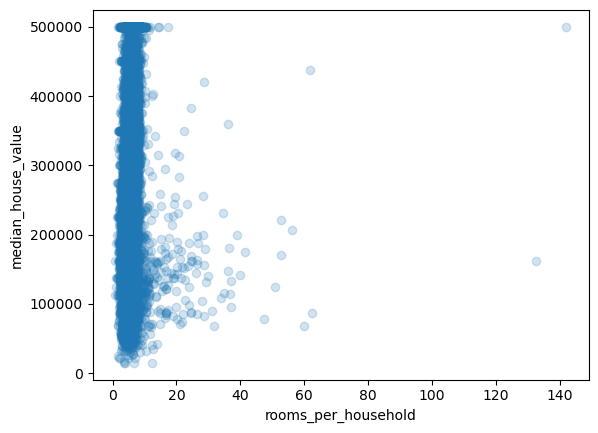

In [9]:
import matplotlib.pyplot as plt

x_plot = housing_data["rooms_per_household"]
y_plot = housing_data["median_house_value"]

plt.scatter(x_plot,y_plot,alpha = 0.2)
plt.xlabel("rooms_per_household")
plt.ylabel("median_house_value")


In [10]:
# housing_data.info()
housing_data.isna().sum()
print(X_test.info())
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 20046 to 3665
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      3921 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   ocean_proximity     4128 non-null   object 
dtypes: float64(8), object(1)
memory usage: 322.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  fl

In [11]:
median = X_train["total_bedrooms"].median()
X_train["total_bedrooms"].fillna(median,inplace = True)

/tmp/ipykernel_6205/4050817955.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["total_bedrooms"].fillna(median,inplace = True)


In [12]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# print(type(X_train))
# X_train = scaler.fit_transform(X_train.select_dtypes(include=['number']))
# # X_test = scaler.transform
# print(X_train.columns)
print(X_train.groupby("ocean_proximity"))
X_train_num = X_train.select_dtypes(include="number")
X_train_cat = X_train.select_dtypes(include="object")

In [13]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_columns = X_train_num.columns
cat_columns = X_train_cat.columns

num_pipeline = Pipeline(
    [("imputer",SimpleImputer(strategy = "median")),
    ("scaler",StandardScaler())]
)

preprocessor = ColumnTransformer(
        transformers = [
        ("num",num_pipeline,num_columns),
        ("cat",OneHotEncoder(),cat_columns)
        ]
)

pipeline = Pipeline([
    ("preprocessor",preprocessor)
])

# pipeline.named_steps["preprocessor"].get_feature_names_out()
# print(X_train.isna().sum())
print(X_test.columns)
X_train_transformed = pipeline.fit_transform(X_train)
# print(X_train_transformed.shape[1])
X_test_transformed = pipeline.transform(X_test)



Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='object')


In [14]:
# Training a model using scikit learn linear regression model

from sklearn.linear_model import LinearRegression as SkLr

model = SkLr()

model.fit(X_train_transformed,y_train)

sk_pred = model.predict(X_test_transformed)
print(sk_pred)






[ 54261.02768976 124430.91772797 255694.95828244 ... 439180.98341181
 120797.55240621 183386.04993584]


<!-- Training a model using scikitlearn linear regression -->

In [15]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from script.linear_regression import LinearRegression

In [16]:
model = LinearRegression(0.01,1000)
model.fit(X_train_transformed, y_train)
# print(type(model.loss_history))
print(X_test_transformed.shape[1])
y_pred = model.predict(X_test_transformed)
print(y_pred)
# print(len(model.w))
# print(model.b)    



13
[ 54827.71880993 119488.74054303 262769.24548991 ... 442442.10679366
 126264.14645913 185351.23896045]


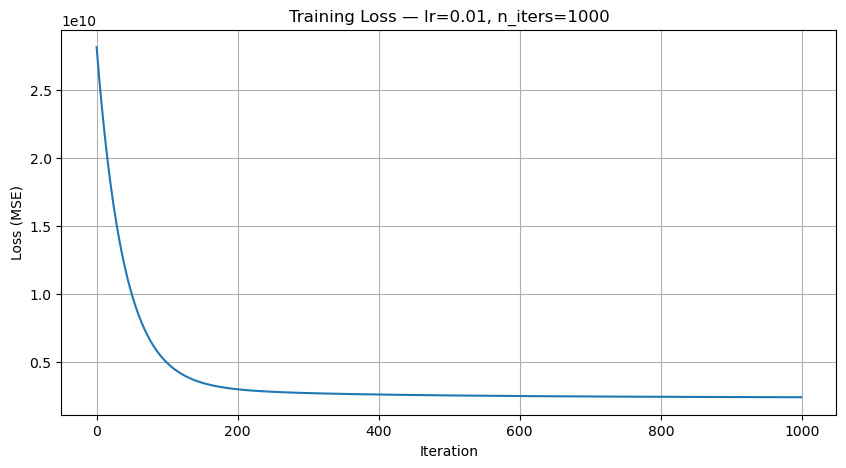

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title(f"Training Loss — lr={model.learning_rate}, n_iters={model.n_iters}")
plt.grid(True)
plt.show()
# plt.semilogy(model.loss_history)

## Evaluating the model using different metrices

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_scratch_model = mean_absolute_error(y_test,y_pred)
mae_sklearn_model = mean_absolute_error(y_test,sk_pred)


print(mae_scratch_model)
print(mae_sklearn_model)


50899.534360760656
50670.48923565361


In [23]:
mse_scratch_model = mean_squared_error(y_test,y_pred)
mse_sklearn_model = mean_squared_error(y_test,sk_pred)

print(mse_scratch_model)
print(mse_sklearn_model)

4982028932.572966
4908290571.346428


In [24]:
from sklearn.metrics import r2_score

r2_scratch = r2_score(y_test, y_pred)
r2_sklearn = r2_score(y_test, sk_pred)

print(f"R² (scratch): {r2_scratch:.4f}")
print(f"R² (sklearn): {r2_sklearn:.4f}")

R² (scratch): 0.6198
R² (sklearn): 0.6254


In [27]:
# Comparing the model with a baseline model
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)


mae_baseline = mean_absolute_error(y_test, baseline_pred)
mse_baseline = mean_squared_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)

print(f"Baseline MAE: ${mae_baseline:,.2f}")
print(f"Baseline MSE: {mse_baseline:,.2f}")
print(f"Baseline R²:  {r2_baseline:.4f}   (should be ~0)")

Baseline MAE: $90,606.85
Baseline MSE: 13,106,960,720.04
Baseline R²:  -0.0002   (should be ~0)
